# `Feature Selection Techniques in Machine Learning`

Welcome! Today we’ll learn about **`Feature Selection`** – one of the most important steps in building a machine learning model. I’ll act as your teacher, explaining **why it is needed**, **how many types of techniques exist**, and then we’ll write code together in a Jupyter Notebook style. Let’s dive in!

---

## 1. Why Do We Need Feature Selection?

Imagine you are trying to predict whether a patient has a disease. You might have hundreds of measurements: blood pressure, age, weight, genetic markers, etc. Not all of them are useful. Some are **`irrelevant`**, some are **`redundant`**, and some may even introduce **`noise`**.


**Feature selection** helps us:

- **`Reduce overfitting`**: Less noise means the model generalizes better.
- **`Improve accuracy`**: Removing misleading data can boost performance.
- **`Reduce training time`**: Fewer features → faster computations.
- **`Enhance interpretability`**: A model with 5 features is easier to explain than one with 500.
- **`Avoid the curse of dimensionality`**: In high dimensions, data becomes sparse and distances lose meaning.

- Note:- The primary objectives are to preserve **`high predictive value`**, **`decrease dimensionality`**, and **`improve interpretability`**.


## 2. How Many Types of Feature Selection Techniques Are There?

There is no fixed number, but we usually classify them into **three main families** (some authors add a fourth “hybrid” category):

#### $\textbf{Filter Methods}$   
   - Rank features using statistical scores, independent of any ML model.  
   - Examples:
   
   1. $\textbf{Variance Threshold}$
      $$\sigma^2 = \frac{1}{N} \sum_{i=1}^{N} (x_i - \mu)^2$$
      
   2. $\textbf{Correlation (Pearson)}$
      $$r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2 \sum (y_i - \bar{y})^2}}$$
      
   3. $\textbf{Chi-Square }(\chi^2)$
      $$\chi^2 = \sum \frac{(O_i - E_i)^2}{E_i}$$      
      
   5. $\textbf{ANOVA (F-Statistic)}$
      $$F = \frac{\text{Variance Between Groups}}{\text{Variance Within Groups}} = \frac{MS_{\text{between}}}{MS_{\text{within}}}$$
      
   6. $\textbf{Mutual Information (MI)}$
      $$I(X; Y) = \sum_{x \in X} \sum_{y \in Y} p(x, y) \log \left( \frac{p(x, y)}{p(x)p(y)} \right)$$


2. #### $\textbf{Wrapper Methods} $ 
   - Use a predictive model to evaluate subsets of features.  
   - Examples: `Recursive Feature Elimination (RFE)`, `Forward/Backward Selection`, `Exhaustive Search`.

3. #### $ \textbf{Embedded Methods} $  
   - Feature selection happens **during** model training.  
   - Examples: `Lasso (L1 regularization)`, `Decision Tree / Random Forest importance`, `Elastic Net`.

4. #### $ \textbf{Hybrid Methods} $ (optional)  
   - Combine filter and wrapper approaches to get the best of both worlds.



## 3. Let's Start

We’ll use a classic dataset: **Breast Cancer Dataset** from `sklearn`. It has 30 numeric features and a binary target.

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
# Load data
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

In [3]:
# Let Check the Rows and Columns
print("Dataset shape:", X.shape)
print("Target classes:", np.unique(y))

Dataset shape: (569, 30)
Target classes: [0 1]


In [4]:
# Split into train and test
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize (important for many feature selection methods)
#scaler = StandardScaler()
#X_train_scaled = scaler.fit_transform(X_train)
#X_test_scaled = scaler.transform(X_test)

## 4. Filter Methods

Filter methods evaluate features **without involving any ML model**. They are fast and good for a first pass.

### 4.1 Variance Threshold

Removes features with low variance (i.e., almost constant values). Those features carry little information.

In [17]:
from sklearn.feature_selection import VarianceThreshold

# Apply variance threshold (remove features with variance below 0.01)
selector = VarianceThreshold(threshold=0.1)
selector.fit(X)

# Get a boolean mask of selected features
selected_mask = selector.get_support()
print(selected_mask)
selected_features = X.columns[selected_mask]

print("Number of selected features:", len(selected_features))
print("Selected features:", selected_features.tolist())

[ True  True  True  True False False False False False False False  True
  True  True False False False False False False  True  True  True  True
 False False False False False False]
Number of selected features: 11
Selected features: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'texture error', 'perimeter error', 'area error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area']


In [18]:
## Lets Train model on different Varience.

In [35]:
from sklearn.linear_model import LogisticRegression
logit_model = LogisticRegression()

In [29]:
Selected_features = X[selected_features]

In [37]:
logit_model.fit(X_train,y_train)

LogisticRegression()

In [10]:
import warnings 
warnings.filterwarnings("ignore")

In [33]:
X_train, X_test, y_train, y_test = train_test_split(Selected_features, y, test_size=0.2, random_state=42)

In [32]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix

In [34]:
y_train_predict = logit_model.predict(X_train)
y_test_predict = logit_model.predict(X_test)
print("Train Accuracy Score:",accuracy_score(y_train,y_train_predict))
print("Testing Accuracy Score:",accuracy_score(y_test,y_test_predict))
print("Recall Training:", recall_score(y_train,y_train_predict))
print("Recall Test:", recall_score(y_train,y_train_predict))
print("precision Training:", precision_score(y_train,y_train_predict))
print("precision Test:", precision_score(y_train,y_train_predict))

Train Accuracy Score: 0.9384615384615385
Testing Accuracy Score: 0.956140350877193
Recall Training: 0.9615384615384616
Recall Test: 0.9615384615384616
precision Training: 0.9417808219178082
precision Test: 0.9417808219178082


In [38]:
Variance = np.arange(0.0,1,0.05) 
for var in Variance:   
    selector = VarianceThreshold(threshold=var)
    selector.fit(X)
    # Get a boolean mask of selected features
    selected_mask = selector.get_support()
    selected_features = X.columns[selected_mask]
    
    print("Number of selected features:", len(selected_features))
    print("Selected features:", selected_features.tolist())
    Selected_features = X[selected_features]
    X_train, X_test, y_train, y_test = train_test_split(Selected_features, y, test_size=0.2, random_state=42)
    print("----------------------------------------------------------")
    print(f"Starting Model Training on {len(selected_features)} Selected Feature and Variance:{var}")
    logit_model.fit(X_train,y_train)
    y_train_predict = logit_model.predict(X_train)
    y_test_predict = logit_model.predict(X_test)
    print("Train Accuracy Score:",accuracy_score(y_train,y_train_predict))
    print("Testing Accuracy Score:",accuracy_score(y_test,y_test_predict))
    print("Recall Training:", recall_score(y_train,y_train_predict))
    print("Recall Test:", recall_score(y_train,y_train_predict))
    print("precision Training:", precision_score(y_train,y_train_predict))
    print("precision Test:", precision_score(y_train,y_train_predict))
    print("----------------------------------------------------------")

Number of selected features: 30
Selected features: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']
----------------------------------------------------------
Starting Model Training on 30 Selected Feature and Variance:0.0
Train Accuracy Score: 0.9538461538461539
Testing Accuracy Score: 0.9473684210526315
Recall Training: 0.9685314685314685
Recall Test: 0.9685314685314685
precision Training: 0.9584775086505191
precision Test: 0.9584775086505191
------------------------

### 4.2 Correlation Matrix

Highly correlated features are redundant. We can visualise and remove one of each pair.

In [48]:
X["target"] = y

In [50]:
X

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


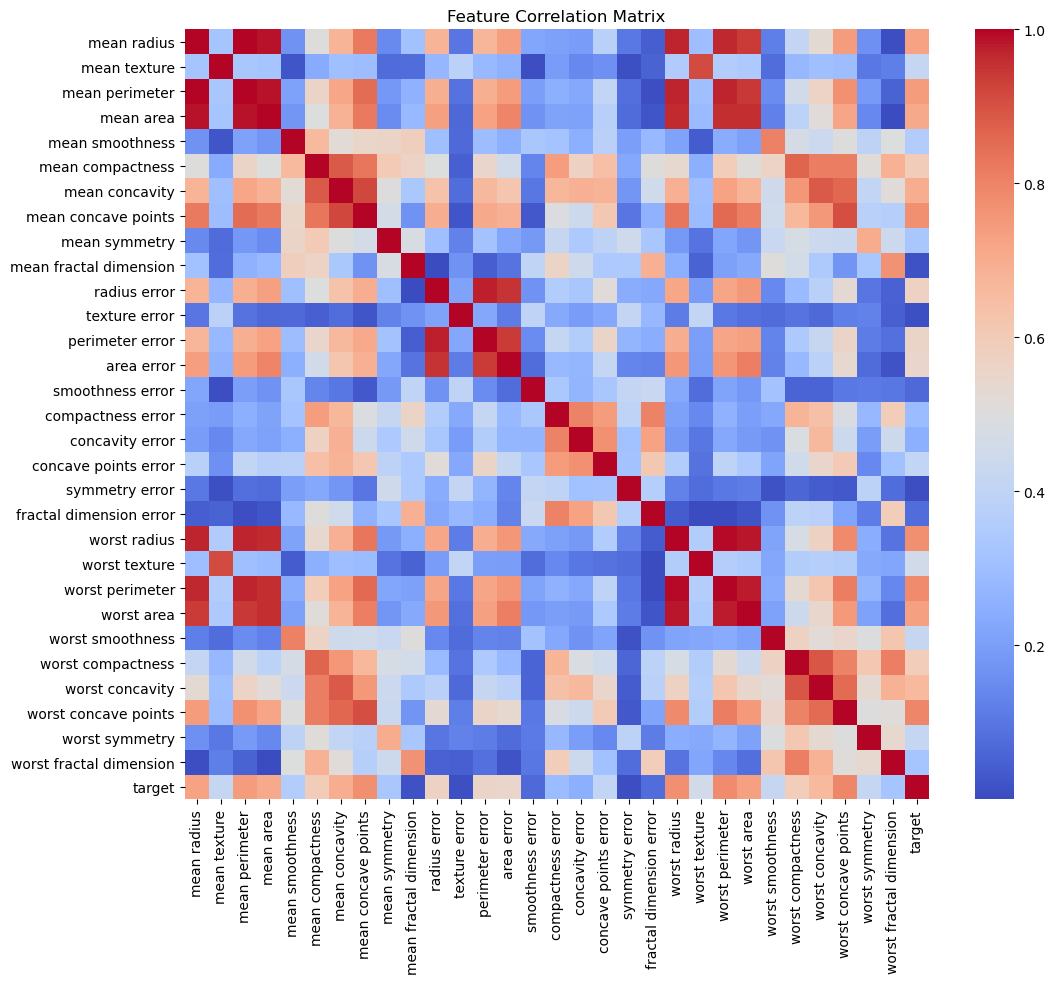

Highly correlated pairs (corr > 0.9): [('mean perimeter', 'mean radius'), ('mean area', 'mean radius'), ('mean area', 'mean perimeter'), ('mean concave points', 'mean concavity'), ('perimeter error', 'radius error'), ('area error', 'radius error'), ('area error', 'perimeter error'), ('worst radius', 'mean radius'), ('worst radius', 'mean perimeter'), ('worst radius', 'mean area'), ('worst texture', 'mean texture'), ('worst perimeter', 'mean radius'), ('worst perimeter', 'mean perimeter'), ('worst perimeter', 'mean area'), ('worst perimeter', 'worst radius'), ('worst area', 'mean radius'), ('worst area', 'mean perimeter'), ('worst area', 'mean area'), ('worst area', 'worst radius'), ('worst area', 'worst perimeter'), ('worst concave points', 'mean concave points')]


In [52]:
# Compute correlation matrix on training data
corr_matrix = pd.DataFrame(X, columns=X.columns).corr().abs()

# Plot heatmap (optional, but nice to see)
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)
plt.title('Feature Correlation Matrix')
plt.show()

# Find pairs with correlation > 0.9
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = [(col, idx) for col in upper.columns for idx in upper.index if upper.loc[idx, col] > 0.9]
print("Highly correlated pairs (corr > 0.9):", high_corr_pairs)

In [64]:
corr = corr_matrix.drop("target")
corr.sort_values(ascending=False, by= "target")

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
worst concave points,0.744214,0.295316,0.771241,0.722017,0.503053,0.815573,0.861323,0.910155,0.430297,0.175325,...,0.359755,0.816322,0.747419,0.547691,0.801080,0.855434,1.000000,0.502528,0.511114,0.793566
worst perimeter,0.965137,0.358040,0.970387,0.959120,0.238853,0.590210,0.729565,0.855923,0.219169,0.205151,...,0.365098,1.000000,0.977578,0.236775,0.529408,0.618344,0.816322,0.269493,0.138957,0.782914
mean concave points,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,0.166917,...,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661,0.776614
worst radius,0.969539,0.352573,0.969476,0.962746,0.213120,0.535315,0.688236,0.830318,0.185728,0.253691,...,0.359921,0.993708,0.984015,0.216574,0.475820,0.573975,0.787424,0.243529,0.093492,0.776454
mean perimeter,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,0.261477,...,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019,0.742636
worst area,0.941082,0.343546,0.941550,0.959213,0.206718,0.509604,0.675987,0.809630,0.177193,0.231854,...,0.345842,0.977578,1.000000,0.209145,0.438296,0.543331,0.747419,0.209146,0.079647,0.733825
mean radius,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,0.311631,...,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066,0.730029
mean area,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,0.283110,...,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738,0.708984
mean concavity,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,0.336783,...,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930,0.696360
worst concavity,0.526911,0.301025,0.563879,0.512606,0.434926,0.816275,0.884103,0.752399,0.433721,0.346234,...,0.368366,0.618344,0.543331,0.518523,0.892261,1.000000,0.855434,0.532520,0.686511,0.659610


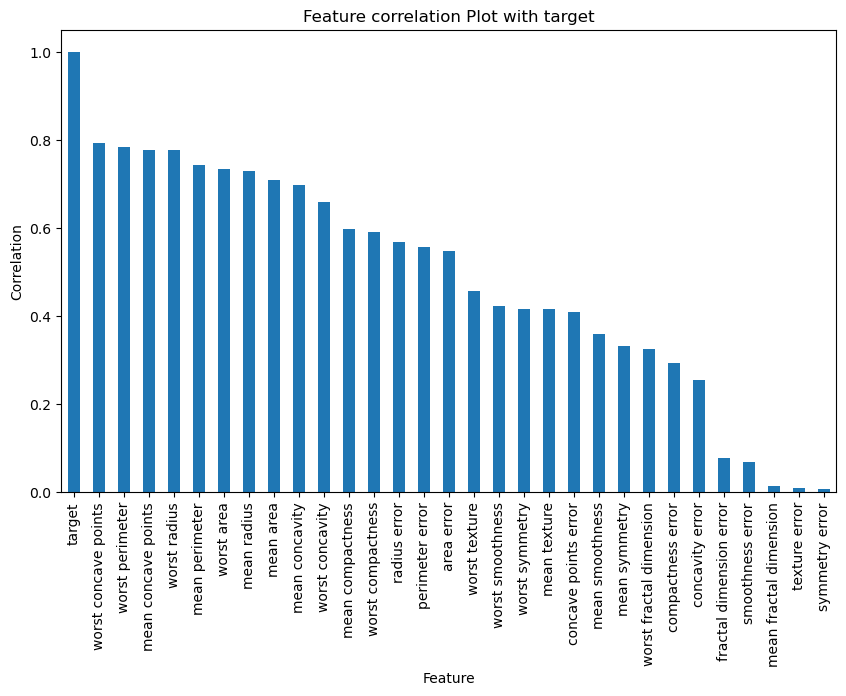

In [86]:
plt.figure(figsize=(10,6))
correlation_target = corr_matrix['target']
correlation_target = correlation_target.sort_values(ascending = False)
correlation_target.plot(kind = "bar")
plt.xlabel("Feature")
plt.ylabel("Correlation")
plt.title("Feature correlation Plot with target")
plt.show()

In [ ]:
# Train a model with features whose correlation with the target is greater than 0.5, 0.4, and 0.6.

> **Note:** Since our data is standardized, variance is around 1 for all features, so this may not remove many. On raw data it can be more useful.

### 4.3 Univariate Selection (SelectKBest)

We rank features using statistical tests and keep the top `k`. For classification we can use `f_classif` (ANOVA) or `chi2`.

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

# Select top 10 features based on ANOVA F-value
k = 10
selector = SelectKBest(score_func=f_classif, k=k)
selector.fit(X_train_scaled, y_train)

# Get selected feature names and scores
scores = selector.scores_
feature_scores = pd.DataFrame({'Feature': X.columns, 'Score': scores})
top_features = feature_scores.nlargest(k, 'Score')

print("Top 10 features by ANOVA F-value:")
print(top_features)

# Transform the data to keep only selected features
X_train_selected = selector.transform(X_train_scaled)
X_test_selected = selector.transform(X_test_scaled)
print("New training shape:", X_train_selected.shape)

## 5. Wrapper Methods

Wrapper methods use a model to evaluate feature subsets. They are more accurate but computationally expensive.

### 5.1 Recursive Feature Elimination (RFE)

RFE recursively removes the least important features according to a model’s coefficients or feature importances.

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

# Use logistic regression as the estimator
model = LogisticRegression(max_iter=1000, random_state=42)

# Select top 10 features using RFE
rfe = RFE(estimator=model, n_features_to_select=10)
rfe.fit(X_train_scaled, y_train)

# Get selected feature names
selected_mask = rfe.support_
selected_features = X.columns[selected_mask]
print("RFE selected features:", selected_features.tolist())

# Transform data
X_train_rfe = rfe.transform(X_train_scaled)
X_test_rfe = rfe.transform(X_test_scaled)

### 5.2 Sequential Feature Selection (Forward/Backward)

`SequentialFeatureSelector` adds (forward) or removes (backward) features one by one, evaluating model performance at each step.

In [ ]:
from sklearn.feature_selection import SequentialFeatureSelector

# Forward selection with logistic regression, using 5-fold cross-validation
sfs = SequentialFeatureSelector(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    n_features_to_select=10,
    direction='forward',   # 'backward' for backward elimination
    cv=5,
    scoring='accuracy'
)
sfs.fit(X_train_scaled, y_train)

selected_features = X.columns[sfs.get_support()]
print("Sequential Forward selected features:", selected_features.tolist())

X_train_sfs = sfs.transform(X_train_scaled)
X_test_sfs = sfs.transform(X_test_scaled)

## 6. Embedded Methods

Embedded methods perform feature selection **as part of the model training process**.

### 6.1 Lasso Regularization (L1)

Lasso adds a penalty that can shrink coefficients to exactly zero – those features are effectively removed.

In [ ]:
from sklearn.linear_model import LogisticRegression

# Logistic Regression with L1 penalty (embedded feature selection)
l1_model = LogisticRegression(penalty='l1', solver='liblinear', C=0.1, random_state=42)
l1_model.fit(X_train_scaled, y_train)

# Features with non-zero coefficients
coef = l1_model.coef_.ravel()
selected_mask = coef != 0
selected_features = X.columns[selected_mask]
print("L1 selected features:", selected_features.tolist())
print("Number of selected features:", len(selected_features))

### 6.2 Tree-Based Feature Importance

Random Forest and Gradient Boosting provide feature importance scores derived from how often a feature is used to split nodes.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Train a Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

# Get feature importances
importances = rf.feature_importances_
feature_importances = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feature_importances = feature_importances.sort_values('Importance', ascending=False)

# Plot top 10
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances.head(10))
plt.title('Top 10 Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()

# Select top 10 features
top10_features = feature_importances.head(10)['Feature'].tolist()
print("Top 10 features by Random Forest importance:", top10_features)

### 6.3 SelectFromModel

`SelectFromModel` uses any model’s feature importance or coefficients to select features above a threshold.

In [ ]:
from sklearn.feature_selection import SelectFromModel

# Use Random Forest importance to select features with importance > mean importance
sfm = SelectFromModel(estimator=RandomForestClassifier(n_estimators=100, random_state=42), threshold='mean')
sfm.fit(X_train_scaled, y_train)

selected_features = X.columns[sfm.get_support()]
print("SelectFromModel selected features:", selected_features.tolist())

X_train_sfm = sfm.transform(X_train_scaled)
X_test_sfm = sfm.transform(X_test_scaled)

## 7. Comparison of Techniques

| Method Type | Pros | Cons |
|-------------|------|------|
| **Filter** | Fast, model-agnostic, good for high-dimensional data | Ignores feature interactions, may select redundant features |
| **Wrapper** | Considers feature interactions, often better performance | Computationally expensive, risk of overfitting to the model |
| **Embedded** | Integrated with training, good trade-off | Specific to the model used, less flexible |

**When to use what?**
- Start with **filter methods** for quick screening.
- If you have a strong model and need high performance, try **wrapper methods**.
- **Embedded methods** are a good default because they balance speed and accuracy.

---

## 8. Conclusion

Today we learned:
- **Why feature selection is essential** – it reduces overfitting, improves accuracy, and speeds up training.
- **The three main categories** – Filter, Wrapper, Embedded (plus hybrids).
- **Practical code examples** for each category using Python and scikit-learn.

You can now apply these techniques to your own datasets. Remember, feature selection is often an iterative process – try different methods and validate using cross-validation.

**Homework**: Take a dataset (e.g., `load_diabetes` or any Kaggle dataset) and apply at least one filter, one wrapper, and one embedded method. Compare the number of selected features and the model performance. Which method worked best? Why do you think that is?

Happy coding! 🚀